In [ ]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np 
import pandas as pd
import datetime
import xarray as xr 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from zhiyi.analysis.SE_analysis import get_site_index 
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
print("done")


done


In [ ]:
SCRIP_file = "/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
SCRIP_file_ne60 ="/home/users/zhiyi/MUSICA_GRIDS/ne0np4.UK_ne30x16/grids/UK_ne30x16_np4_SCRIP.nc"
filebase_ne30 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0/atm/hist/MUSICA_production3.0.cam.h3.YYYY-MM-DD-00000.nc')
filebase_ne60 = ('/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MUSICA_production3.0_NOBB/atm/hist/MUSICA_production3.0_NOBB.cam.h3.YYYY-MM-DD-00000.nc')

city_lonlat = {
    'London':    [360 - 0.213492,  51.521050],
    'Manchester':[360 - 2.237881, 53.481520],
    # 'Edingurgh': [360 - 3.182186, 55.945589],
    'Glasgow':   [360 - 4.259122, 55.858940],
    'Birmingham': [360 - 1.874978, 52.476145],
    # 'Belfast':   [360 - 5.9301, 54.5973],
    # 'Glasgow':   [360 - 4.2576, 55.8651],
    # 'Bristol':   [360 - 2.5879, 51.4545],
}

In [ ]:
def collect_files(template, start, end):
    files = []
    by_day = ("DD" in template)

    cur = start
    while cur <= end:
        YYYY = cur.strftime("%Y")
        MM   = cur.strftime("%m")
        DD   = cur.strftime("%d")
        f = (template
             .replace("YYYY", YYYY)
             .replace("MM", MM)
             .replace("DD", DD))
        if os.path.exists(f):
            files.append(f)
        else:
            print(f"Warning: File not found - {f}, skipping.")
        if by_day:
            cur += datetime.timedelta(days=1)
        else:
            if cur.month == 12:
                cur = datetime.date(cur.year + 1, 1, 1)
            else:
                cur = datetime.date(cur.year, cur.month + 1, 1)
    if not files:
        raise FileNotFoundError(
            f"No files found for template '{template}' between {start} and {end}."
        )
    return files

def get_obs_series(obs_df, station_to_col, station, start, end):
    col = station_to_col[station]
    s = pd.to_numeric(obs_df[col], errors='coerce')
    return s[start:end]

def build_kdtree(ds):
    lon360 = ds['lon'].isel(time=0).values
    lat    = ds['lat'].isel(time=0).values
    lon180 = (lon360 + 180) % 360 - 180
    tree   = cKDTree(np.vstack([lat, lon180]).T)
    return tree, lon360, lat, lon180

def get_3x3_minmax(ds, tree, lon180_all, city_lon, city_lat, k=9):
    lon180_c = (city_lon + 180) % 360 - 180
    _, idx9  = tree.query([city_lat, lon180_c], k=k)
    pm9 = ds['PM25'][:, -1, idx9].values * 1e9
    return np.nanmin(pm9, axis=1), np.nanmax(pm9, axis=1)

scrip30 = xr.open_dataset(SCRIP_file)
scrip60 = xr.open_dataset(SCRIP_file_ne60)

se_files_30 = collect_files(filebase_ne30, start_date, end_date)
se_files_60 = collect_files(filebase_ne60, start_date, end_date)

ds_ne30 = xr.open_mfdataset(se_files_30, combine="by_coords")
ds_ne60 = xr.open_mfdataset(se_files_60, combine="by_coords")

print("Datasets loaded!")

Datasets loaded!


In [ ]:

Index_lonlat_30 = {}
Index_lonlat_60 = {}

for city, (lon360_c, lat_c) in city_lonlat.items():
    Index_lonlat_30[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file
    )
    Index_lonlat_60[city] = get_site_index(
        lon360_c, lat_c,
        scrip_file=SCRIP_file_ne60
    )

TS     = {}
TS_f09 = {}
for city in city_lonlat:
    idx30 = Index_lonlat_30[city]
    idx60 = Index_lonlat_60[city]
    TS[city]     = ds_ne30['PM25'].values[:, -1, idx30] * 1e9
    TS_f09[city] = ds_ne60['PM25'].values[:, -1, idx60] * 1e9

time_values      = pd.to_datetime(ds_ne30.time.values)
time_values_nobb = pd.to_datetime(ds_ne60.time.values)

tree_30, lon360_30, lat_30, lon180_30 = build_kdtree(ds_ne30)
tree_60, lon360_60, lat_60, lon180_60 = build_kdtree(ds_ne60)

pm_min_30   = {}
pm_max_30   = {}
pm_min_60   = {}
pm_max_60   = {}
for city, (lon_c, lat_c) in city_lonlat.items():
    mn30, mx30 = get_3x3_minmax(
        ds_ne30, tree_30, lon180_30, lon_c, lat_c, k=9)
    mn60, mx60 = get_3x3_minmax(
        ds_ne60, tree_60, lon180_60, lon_c, lat_c, k=9)
    pm_min_30[city], pm_max_30[city] = mn30, mx30
    pm_min_60[city], pm_max_60[city] = mn60, mx60


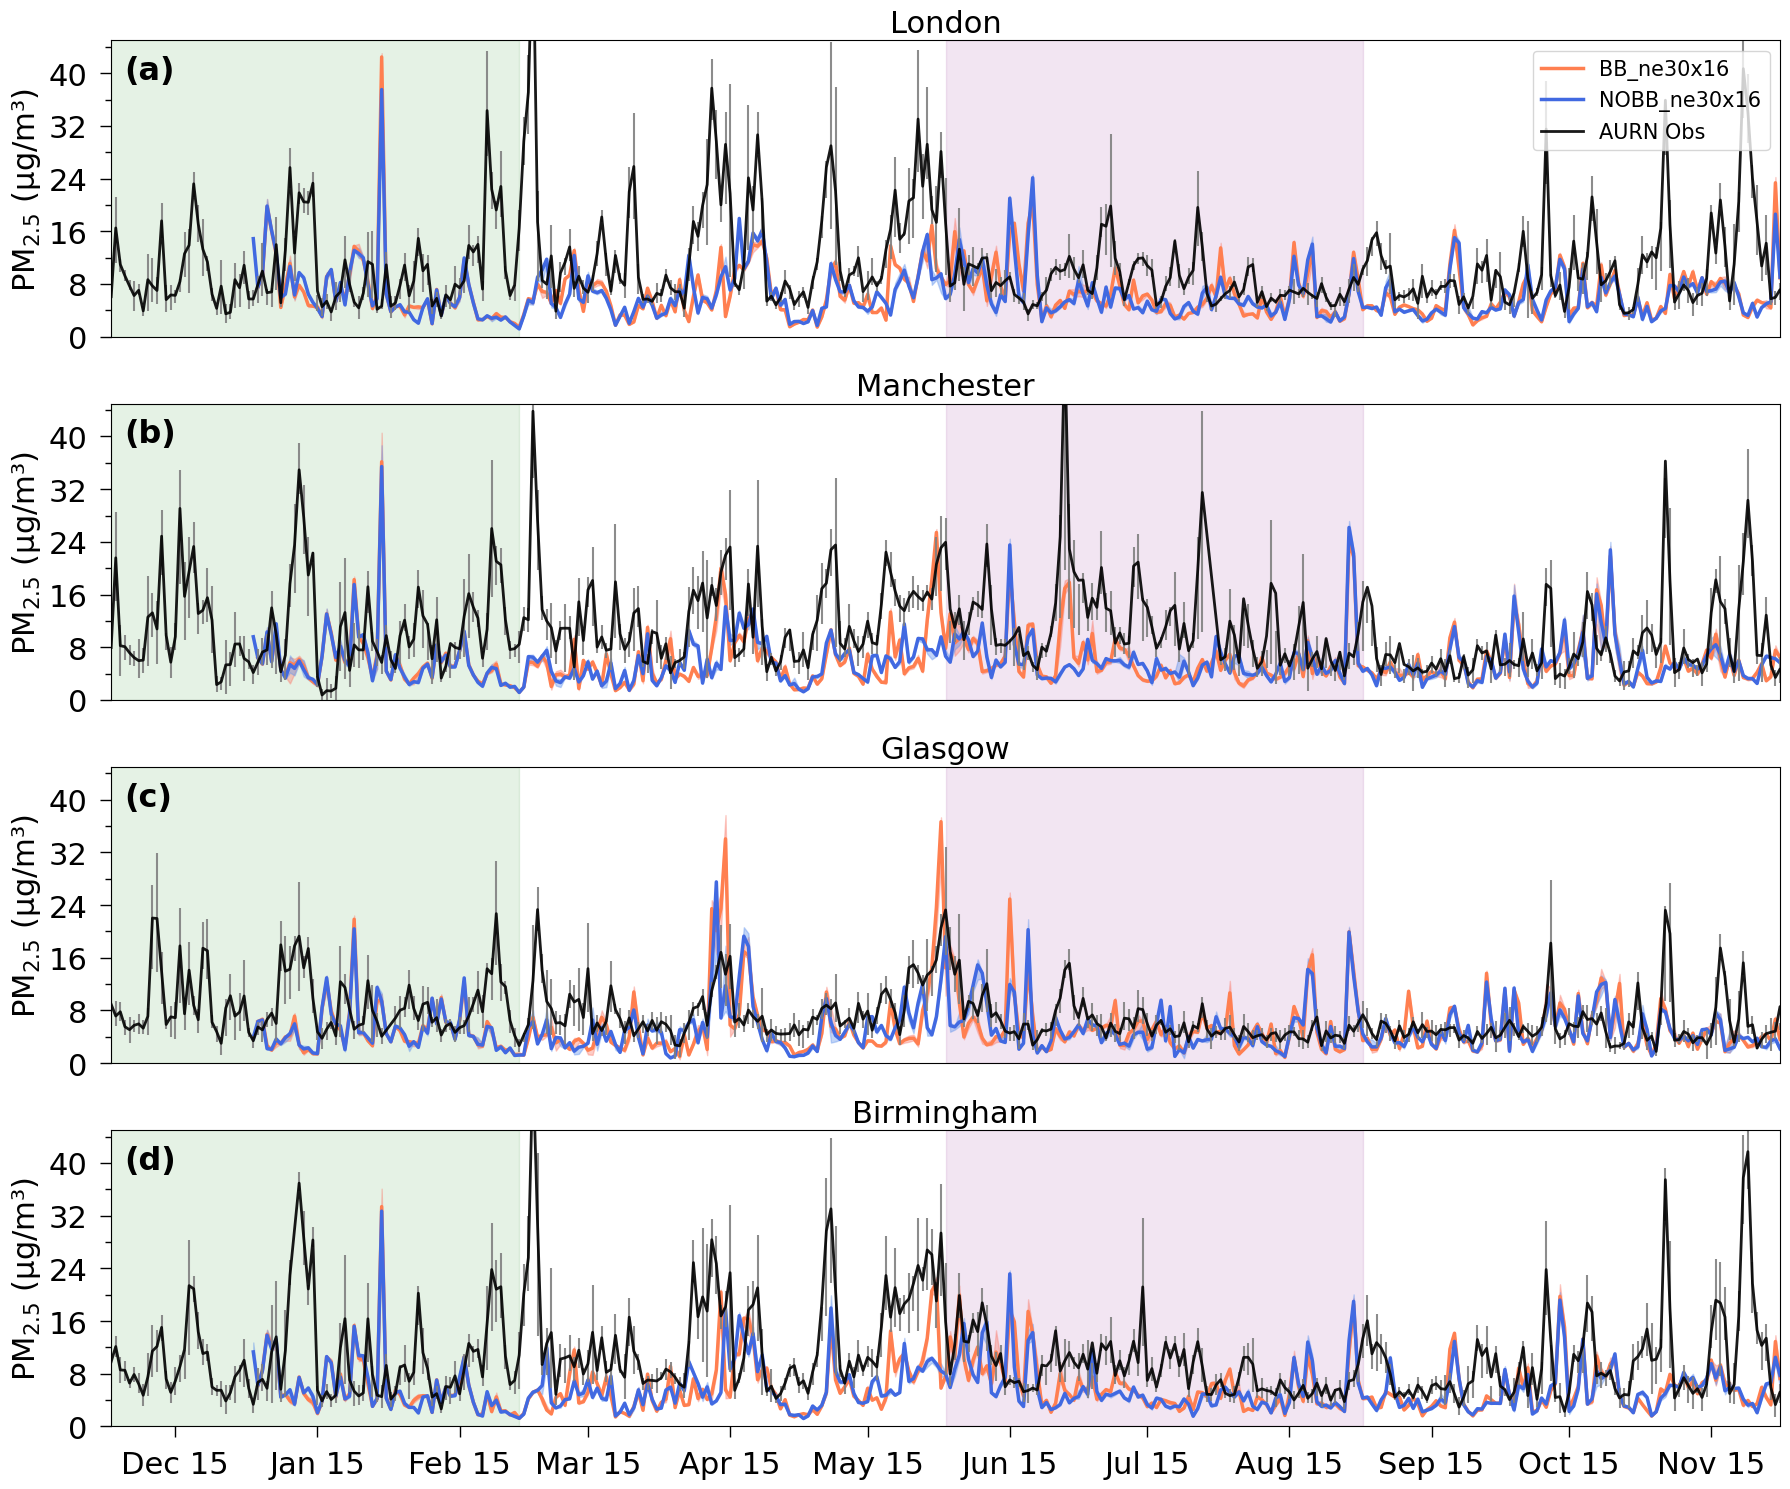

In [ ]:

def make_daily_stats(csv_path, ycol='average', start_date=None, end_date=None):
    df = pd.read_csv(csv_path)
    df['Date'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), errors='coerce')
    m = (df['Date'] >= start_date) & (df['Date'] <= end_date)
    daily = (
        df.loc[m].set_index('Date')
          .resample('D')[ycol]
          .agg(mean='mean',
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75))
          .reset_index()
          .sort_values('Date')
    )
    return daily

cities = list(city_lonlat.keys())
fig, axes = plt.subplots(4, 1, figsize=(18, 15))

month_locator   = mdates.MonthLocator(bymonthday=15)  
month_formatter = mdates.DateFormatter('%b %d')
ycol = 'average'
start_date = pd.to_datetime('2017-12-01')
end_date   = pd.to_datetime('2018-12-31')

obs_lon_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/london_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_man_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/manchester_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_gla_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/glasgow_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)
obs_bir_daily = make_daily_stats('/home/users/zhiyi/PROJECTS_ANALYSIS/preprocess_obs_data/processed_data/P1_pm25/birmingham_pm2.5.csv',
                                 ycol=ycol, start_date=start_date, end_date=end_date)

time_values_bst = (pd.to_datetime(time_values.astype('datetime64[ns]'))
                   .tz_localize('UTC')
                   .tz_convert('Europe/London'))
time_values_nobb_bst = (pd.to_datetime(time_values_nobb.astype('datetime64[ns]'))
                        .tz_localize('UTC')
                        .tz_convert('Europe/London'))
obs_daily_map = {
    0: obs_lon_daily,
    1: obs_man_daily,
    2: obs_gla_daily,
    3: obs_bir_daily,
}

for i, city in enumerate(cities):
    ax = axes[i]
    ax.fill_between(time_values_bst,      pm_min_30[city], pm_max_30[city], alpha=0.4 , color='salmon')
    ax.plot(time_values_bst,      TS[city].squeeze(),     color='coral',        linewidth=2.5, label='BB_ne30x16')   
    ax.fill_between(time_values_nobb_bst, pm_min_60[city], pm_max_60[city],     alpha=0.4,      color='cornflowerblue')
    ax.plot(time_values_nobb_bst, TS_f09[city].squeeze(), color='royalblue',    linewidth=2.5, label='NOBB_ne30x16')
    ax.axvspan(pd.to_datetime('2017-12-01'), pd.to_datetime('2018-02-28'), color='green', alpha=0.1, zorder=0)
    ax.axvspan(pd.to_datetime('2018-06-01'), pd.to_datetime('2018-08-31'), color='purple', alpha=0.1, zorder=0)

    obs_daily = obs_daily_map[i]
    valid_iqr  = obs_daily.dropna(subset=['q25', 'q75'])
    valid_mean = obs_daily.dropna(subset=['mean'])

    ax.vlines(
        valid_iqr['Date'], valid_iqr['q25'], valid_iqr['q75'],
        color='grey', linewidth=1.5, alpha=0.9,
        label=None if i == 0 else None
    )

    ax.plot(
        valid_mean['Date'], valid_mean['mean'],
        color='black', linewidth=2, alpha=0.9,
        label='AURN Obs' if i == 0 else None
    )

    ax.set_title(city, fontsize=22)
    ax.xaxis.set_major_locator(month_locator)
    ax.xaxis.set_major_formatter(month_formatter)

    plot_start_x = pd.Timestamp('2017-12-01')
    plot_end_x   = pd.Timestamp('2018-11-30')
    ax.set_xlim(pd.Timestamp(plot_start_x), pd.Timestamp(plot_end_x))
    
    plt.setp(ax.get_yticklabels(), fontsize=20)
    if i in [0, 1, 2]:
        ax.tick_params(axis='x', which='both', labelbottom=False)
        ax.set_xticks([])
    else:
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=25)
        ax.tick_params(axis='x', which='major', labelsize=22, pad=9, length=8, width=1)
        ax.tick_params(axis='x', which='minor', labelsize=18*0.8, length=4, width=1)

    ax.set_ylabel('PM$_{2.5}$ (µg/m³)', fontsize=22)
    ax.yaxis.set_major_locator(MultipleLocator(8))
    ax.set_ylim(0, 45)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis='y', which='major', labelsize=22, pad=9, length=8, width=1)
    ax.tick_params(axis='y', which='minor', labelsize=18*0.8, length=4, width=1)

    if i == 0:
        ax.legend(fontsize=15, loc='upper right')

    letters = ['(a)', '(b)', '(c)', '(d)']
    ax.text(0.008, 0.95, letters[i], transform=ax.transAxes, fontsize=23, va='top', ha='left', weight='bold')

plt.tight_layout(h_pad=1.3)

